# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [ ]:
#! pip3 install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 39.7 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 33.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 38.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 44.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [tensorflow]0 [tensorflow]a]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [31]:
#importing other libraries
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [12]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train_all=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test_all=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])

X_Train_raw=np.array(Train_Sample[RawNames])
X_Test_raw=np.array(Test_Sample[RawNames])

#for high level engineered features
X_Train_feat=np.array(Train_Sample[FeatureNames])
X_Test_feat=np.array(Test_Sample[FeatureNames])


In [13]:
###  Standarizing each input set
def scale(X_trai, X_tes):
    scaler=StandardScaler()                     #creating a instance
    return scaler.fit_transform(X_trai),scaler.transform(X_tes)

X_Train_all_s, X_Test_all_s= scale(X_Train_all,X_Test_all)
X_Train_raw_s,X_Test_raw_s=scale(X_Train_raw,X_Test_raw)
X_Train_feat_s, X_Test_feat_s=scale(X_Train_feat, X_Test_feat)

print(f"Train size:",X_Train_all_s.shape)
print(f"Test Size:",X_Test_all_s.shape)

Train size: (500000, 18)
Test Size: (50000, 18)


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [20]:
def plot_history(history, title="Model's Training History"):
    #Creating a two side by side subplots in a canvas
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(title,fontsize=15, fontweight='bold')

    ## for loss over epochs. Training loss: measures how good a model is fitting with training data; Validation loss measures generalization to unseen data
    ax=axes[0]
    ax.plot(history.history['loss'], label='Train loss', linewidth=2)
    ax.plot(history.history['val_loss'],label='Validation Loss', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Cross-Entropy Loss')
    ax.set_title('Loss vs Epoch')
    ax.legend()
    ax.grid(True, alpha=0.25)

    # for accuracy over epoch. Training accuracy for performance on the training set of the data; validation accuracy for performance on held out set of the data
    ax=axes[1]
    ax.plot(history.history['accuracy'],label='Train accuracy', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Validation accuracy', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epoch')
    ax.legend()
    ax.grid(True,alpha=0.25)

    plt.tight_layout()
    plt.show()

    #extracting the total number of epochs the model was trained for and displaying it
    final_epoch=len(history.history['loss'])
    print(f"Epoch trained:{final_epoch}")

    # displaying final training and validation metrics at the last epoch
    print(f" Final train loss={history.history['loss'][-1]:.4f}, acc={history.history['accuracy'][-1]:.4f}")

    print(f"Final val loss={history.history['val_loss'][-1]:.4f}, acc={history.history['val_accuracy'][-1]:.4f}")

    #computing a gap between validation loss and training loss as a proxy for overfitting
    # positive gap indicates model performance is worse on unseen data

    gap=history.history['val_loss'][-1]-history.history['loss'][-1]

    if gap > 0.02:
        print(f"Possible over_trained detected (val_loss - train_loss)= {gap:.4f}")
    else:
        print(f"No significant over-training (val_loss-train_loss)={gap:.4f}")


## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.


Training on RAW (low-level) features
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.


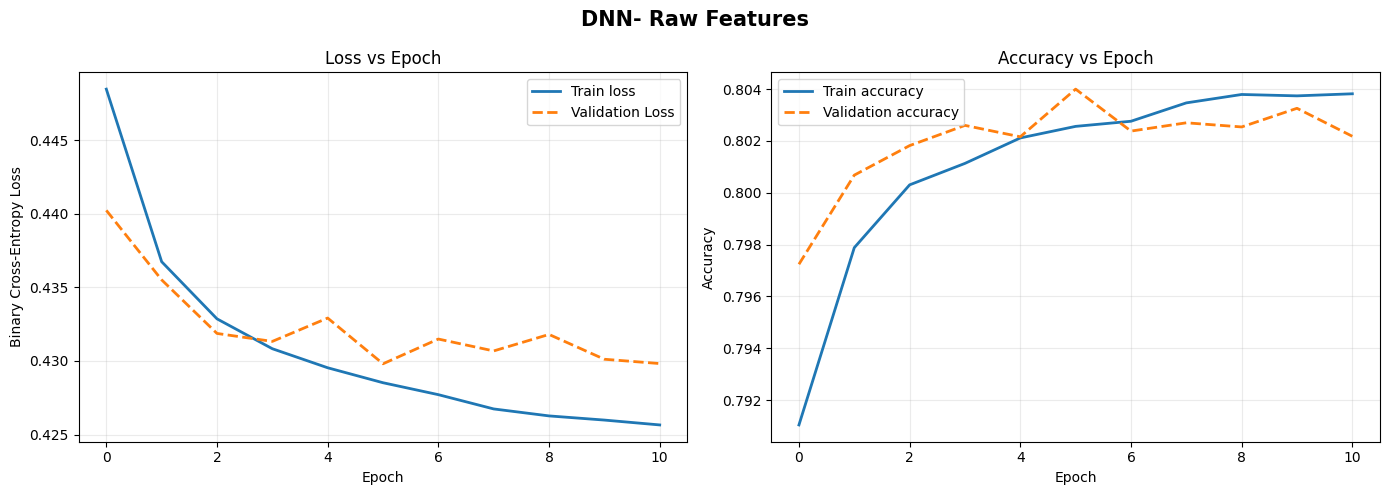

Epoch trained:11
 Final train loss=0.4257, acc=0.8038
Final val loss=0.4298, acc=0.8022
No significant over-training (val_loss-train_loss)=0.0042
 
Training on high level engineered features
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


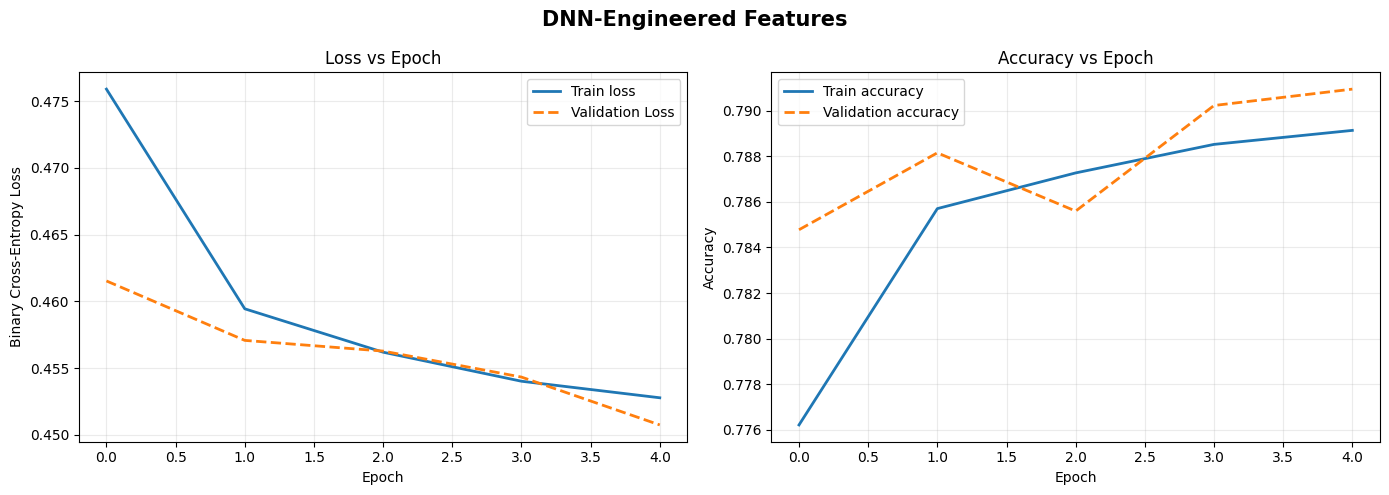

Epoch trained:5
 Final train loss=0.4528, acc=0.7891
Final val loss=0.4507, acc=0.7910
No significant over-training (val_loss-train_loss)=-0.0020
 
Training on All features(Raw+ Engineered)
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


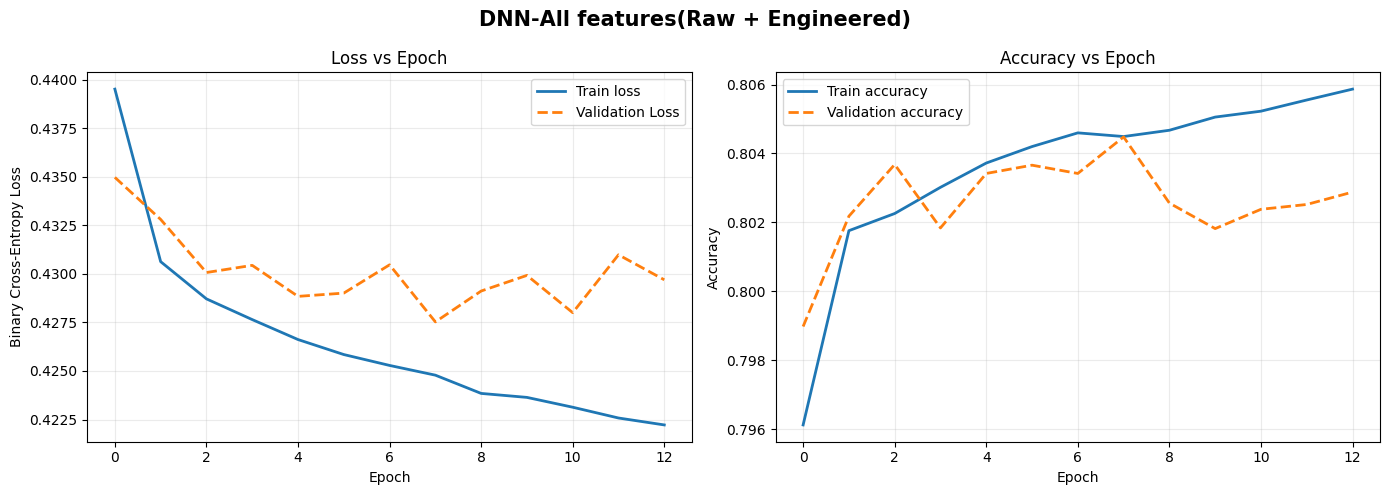

Epoch trained:13
 Final train loss=0.4222, acc=0.8059
Final val loss=0.4297, acc=0.8029
No significant over-training (val_loss-train_loss)=0.0075


In [26]:
def build_baseline_dnn(input_dim,name='DNN'):
    # Creating a sequential model consisting of three hidden layers, each with 300 neurons and ReLU activation
    model=keras.Sequential(
        [
            layers.Input(shape=(input_dim,),name='input'),
            layers.Dense(300, activation='relu'),
            layers.Dense(300,activation='relu'),
            layers.Dense(300,activation='relu'),
            layers.Dense(1, activation= 'sigmoid', name='output'),
        ], name= name
    )

    #compinling the model using the Adam optimizer
    # we use this for adaptation of learning rate,Binary cross entropy as loss function, and Accuracy as secondary metric alongside loss
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Defining an Earlystopping callback to halt training if validation loss does not improve for 5 consecutive epochs
es= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Training for the raw features
# Baseline DNN is trained on the raw feature for establishing performance reference.
#input dimension is inferred from the scaled training matrix at the runtime. 

print("")
print("=="*50)
print("Training on RAW (low-level) features")
model_raw= build_baseline_dnn(X_Train_raw_s.shape[1],name='DNN_Raw')
hist_raw=model_raw.fit(
    X_Train_raw_s,y_Train,
    epochs=50, batch_size=1024,                                 #batch size of 1024 is used to balance gradient stability 
    validation_split=0.1,                                       #validation split is 10% if the training data to monitor generalization
    callbacks=[es], verbose=0
)
plot_history(hist_raw,"DNN- Raw Features")


# Training for engineered features
# It isloates the contribution of domain-specific feature engineering to model performance independent of architectural differences

print(" ")
print("=="* 50)
print("Training on high level engineered features")
model_feat= build_baseline_dnn(X_Train_feat_s.shape[1], name='DNN_Features')
hist_feat=model_feat.fit(
    X_Train_feat_s, y_Train,
    epochs=50, batch_size=1024, validation_split=0.1,callbacks=[es], verbose=0)

plot_history(hist_feat,"DNN-Engineered Features")

#Training for all features
print(" ")
print("=="* 50)
print("Training on All features(Raw+ Engineered)")
model_all=build_baseline_dnn(X_Train_all_s.shape[1],name='DNN_All')
hist_all= model_all.fit(
    X_Train_all_s, y_Train,
    epochs=50, batch_size=1024,
    validation_split=0.1,callbacks=[es], verbose=0
)
plot_history(hist_all,"DNN-All features(Raw + Engineered)")



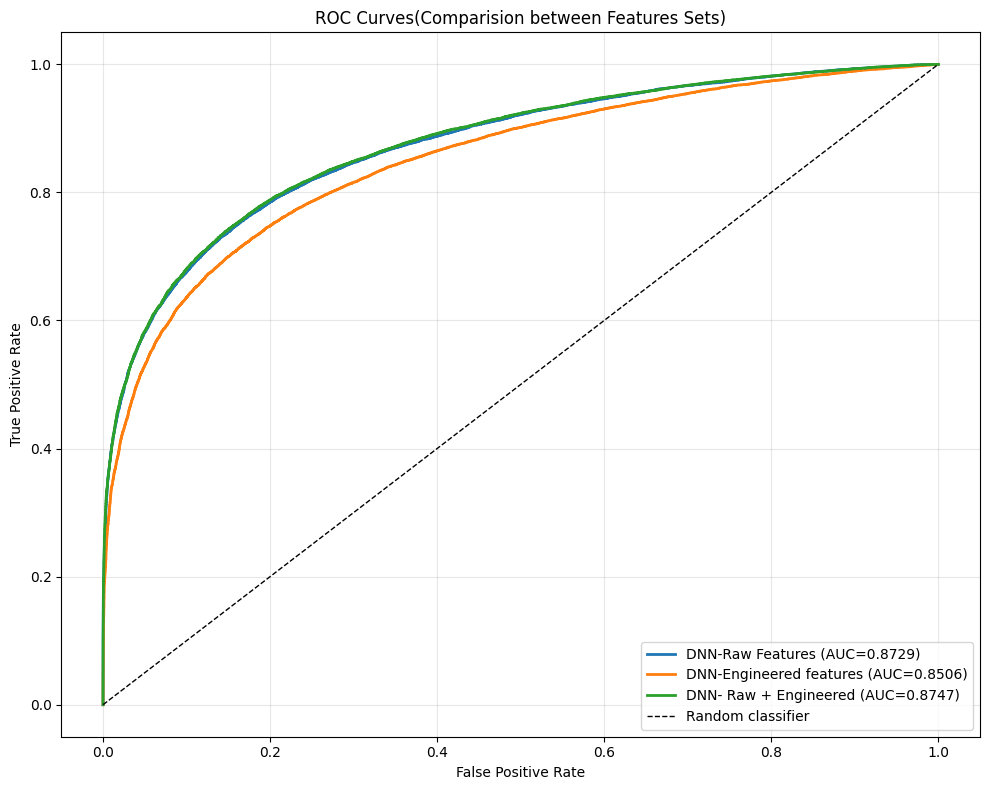

In [27]:
def plot_roc_curves(models_dict,title="ROC Curve Comparison"):
    #Plot ROC curves for multiple models. 
    plt.figure(figsize=(10,8))

    #Loop over each model in the dictionary. 
    # Then for each model generate predict probability score(test set) and compute ROC curve with AUC metric

    for label, (model, X_te, y_te) in models_dict.items():
        y_score=model.predict(X_te,verbose=0).ravel()
        fpr,tpr,_=roc_curve(y_te,y_score)
        roc_auc=auc(fpr,tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.4f})")

    #plotting the diagonal reference line representing a random classifer (AUC=0.5)
    plt.plot([0,1],[0,1],'k--',linewidth=1, label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#Compare all features combinations. Format "DNN-feature_Combination":(model_name,x_test(for corresponding combination),y_test)

ex2_models={
    "DNN-Raw Features": (model_raw, X_Test_raw_s, y_Test),
    "DNN-Engineered features": (model_feat, X_Test_feat_s, y_Test),
    "DNN- Raw + Engineered": (model_all, X_Test_all_s, y_Test),
}
plot_roc_curves(ex2_models,title="ROC Curves(Comparision between Features Sets)")

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

I try three architectures that very depth, width , and optimizer
<br>
1. Shallow wide : 2*512 architecture with adam optimizer and None Regularizations <br>
2. Deep narrow: 5* 128 with adam optimizer and None Regularizations <br>
3. Deep + Dropout: 4*256+ Dropout(0.3), Adam optimizer and Dropout Regularization


Training model A- Shallow Wide


Model: "A_Shallow_Wide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 512)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,897 (1.04 MB)

 Trainable params: 272,897 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

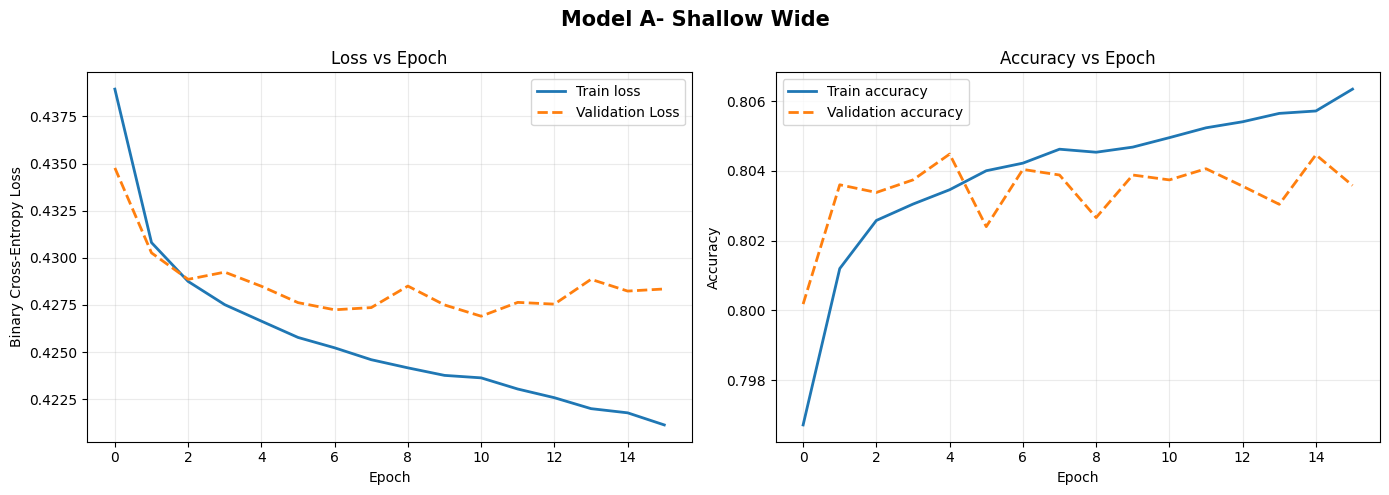

Epoch trained:16
 Final train loss=0.4211, acc=0.8063
Final val loss=0.4283, acc=0.8036
No significant over-training (val_loss-train_loss)=0.0072

Training model B-Deep Narrow


Model: "B_Deep_Narrow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,609 (268.00 KB)

 Trainable params: 68,609 (268.00 KB)

 Non-trainable params: 0 (0.00 B)

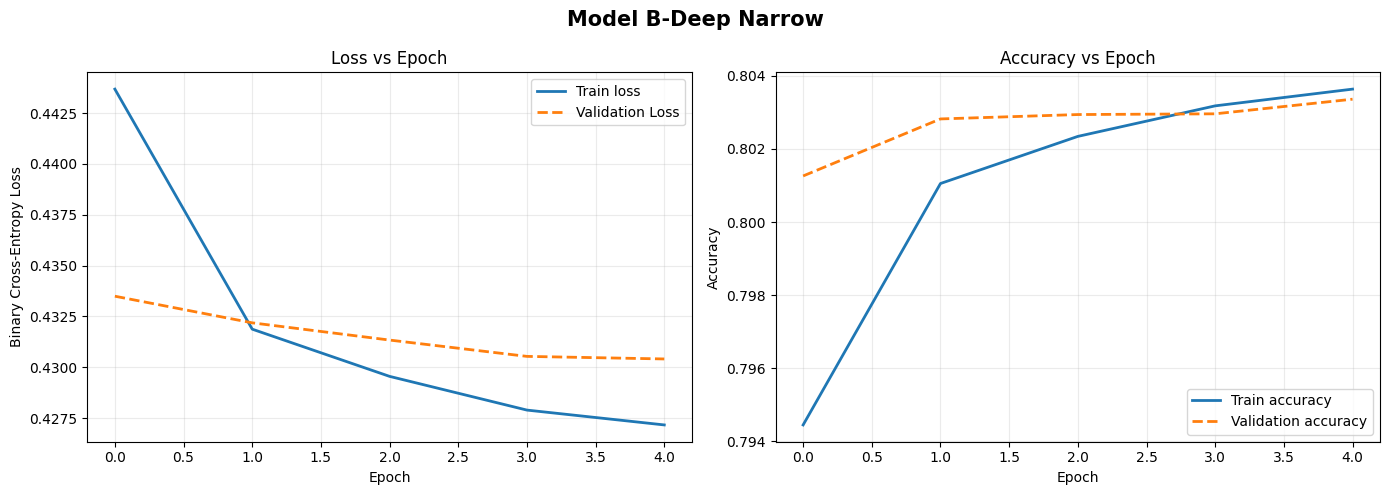

Epoch trained:5
 Final train loss=0.4272, acc=0.8036
Final val loss=0.4304, acc=0.8034
No significant over-training (val_loss-train_loss)=0.0032

Training model C-Deep Dropout


Model: "C_Deep_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,497 (791.00 KB)

 Trainable params: 202,497 (791.00 KB)

 Non-trainable params: 0 (0.00 B)

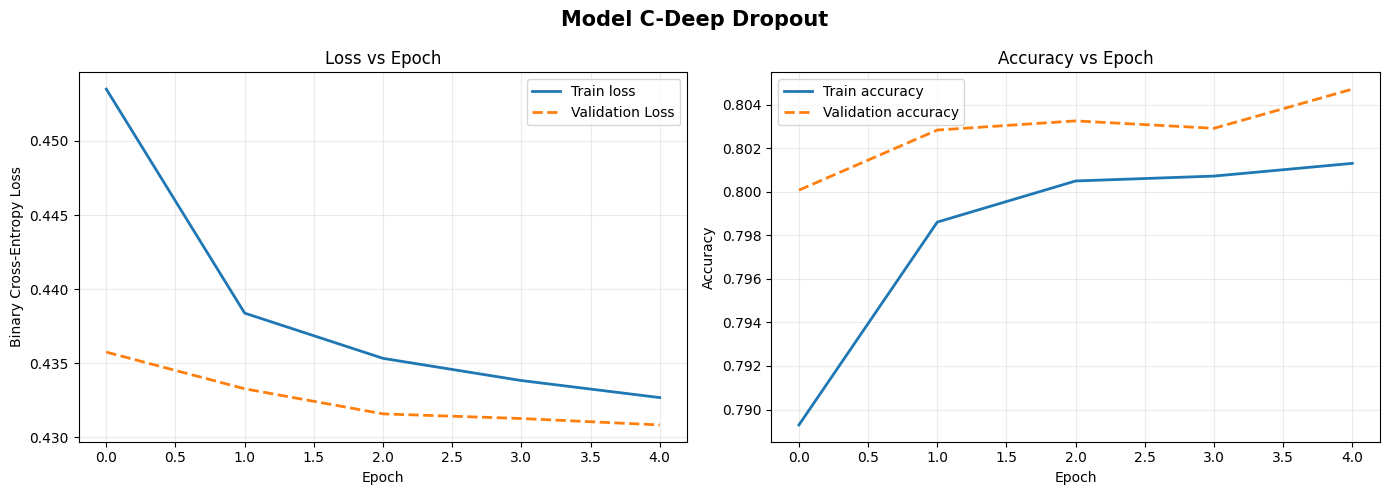

Epoch trained:5
 Final train loss=0.4327, acc=0.8013
Final val loss=0.4308, acc=0.8047
No significant over-training (val_loss-train_loss)=-0.0018


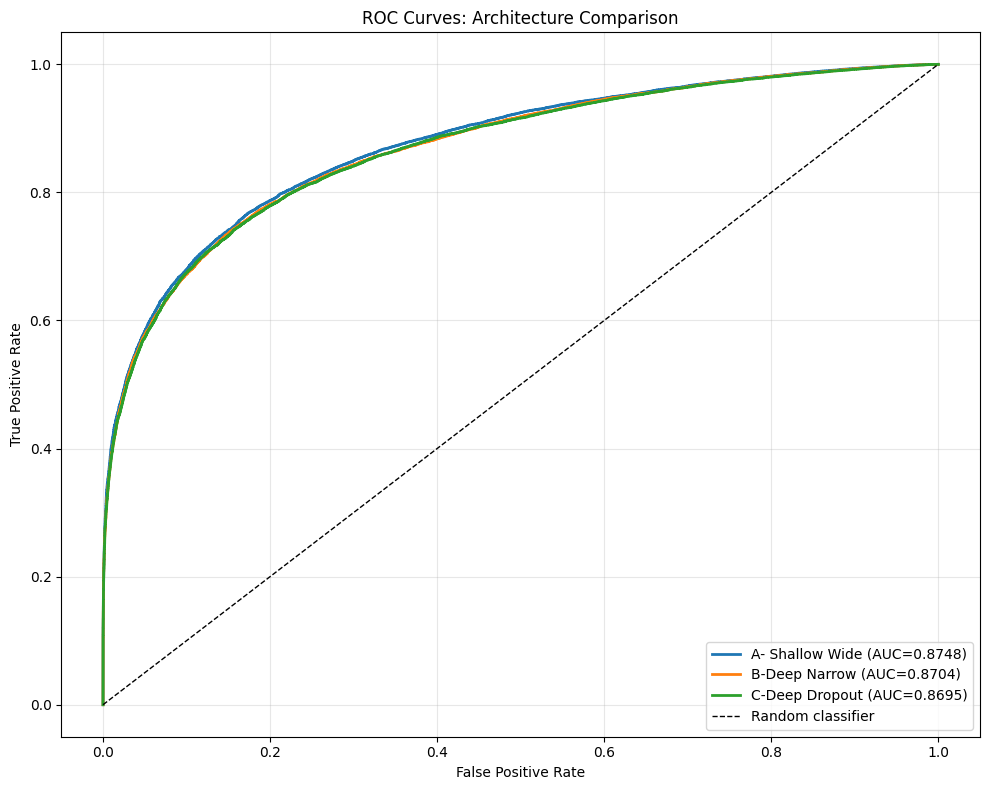

In [29]:
# Determine the input dimensionality from the full feature matrix (raw+ engineered)
input_dim= X_Train_all_s.shape[1]       #use all features for architecture comparision

#Model A: Shallow and Wide 
#It uses two hidden layers with large number of units (512) per layer.
# Width allows the network to learn a broad set of feature interactions in fewer
# Compositional steps, at the cost of a higher parameter count per layer

def build_model_A(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="A_Shallow_Wide")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#Model B : Deep and Narrow
#It increases depth to 5 hidden layers while reducing width to 128 units per layer.

def build_model_B(imput_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="B_Deep_Narrow")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#Model C: Deep + Dropout
#It is a four-layer deep network with drop out regularization.
#After each of the first three hidden layers, at each training step, dropout randomly deactivates 30% of the neurons, which discourages
# co-adaptation and acts as an implicit ensembele method, improving generalization to unseen data.
#Drop out is omitted before the output layer to preserve stable probability estimates at inference time

def build_model_C(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="C_Deep_Dropout")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Early stopping callback for the experiment
# Training halts if validation loss fails to improve for 5 consecutive epochs, and the weights from the best performing epochs are restored automatically
es= EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True, verbose=0)

# Defining et of architectures to be evaluated: each as (label, builder) pair.
architecture_configs=[
    ("A- Shallow Wide", build_model_A),
    ("B-Deep Narrow", build_model_B),
    ("C-Deep Dropout", build_model_C)
]

#Iterate over each architecture, initialize model, print its structure summary, and traind under identical conditions
trained_models = {}
for label, builder in architecture_configs:
    print(f"\n{'='*55}")
    print(f"Training model {label}")
    m = builder(input_dim)
    m.summary()
    hist = m.fit(
        X_Train_all_s, y_Train,
        epochs=50, batch_size=1024,
        validation_split=0.1,
        callbacks=[es], verbose=0
    )
    plot_history(hist, f"Model {label}")
    
    # Each trained model is stored in trained_models alongside its test partition, so all four can be passed to plot_roc_curves for a unified evaluation.
    trained_models[label] = (m, X_Test_all_s, y_Test)

#Plot ROC curve for all four architectures
plot_roc_curves(trained_models, "ROC Curves: Architecture Comparison")


#### Identifying the best DNN-- The one with the highest AUC

In [32]:
# Predict on the test set of each model and record its AUC score
auc_scores={}
for label,(model,X_te,y_te) in trained_models.items():
    y_score=model.predict(X_te,verbose=0).ravel()
    auc_scores[label]=roc_auc_score(y_te,y_score)
    print(f"{label:30s} AUC={auc_scores[label]:.4f}")

#select the best model, one with the highest AAUC, as the best-performing architecture
best_label=max(auc_scores,key=auc_scores.get)
best_model,best_X_test,_=trained_models[best_label]

#print
print(f"\n Best DNN:{best_label} (AUC={auc_scores[best_label]:.4f})")

A- Shallow Wide                AUC=0.8748
B-Deep Narrow                  AUC=0.8704
C-Deep Dropout                 AUC=0.8695

 Best DNN:A- Shallow Wide (AUC=0.8748)


## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


#### Adding best DNN to the traditional ML models from Lab 8 and comparing everything on a single ROC plot

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Use the full all-features set for a fair comparison
X_sk_train = X_Train_all_s
y_sk_train = y_Train

# Defining the three models used in Lab 8
sklearn_models={
    'NB_Model': GaussianNB(),                                               #Naive Bayes Model
    'DT_Model': DecisionTreeClassifier(max_depth=5,min_samples_leaf=50),    #Decision Tree Model
    'Boost_Model':HistGradientBoostingClassifier(random_state=42)           #Gradient Boost Model
}

ex4_models={}   # will collect everything for final ROC plot

for name,clf in sklearn_models.items():
    print(f"Training {name} ..", end=" ")
    clf.fit(X_sk_train,y_sk_train)
    y_score=clf.predict_proba(X_Test_all_s)[:,1]
    roc_auc=roc_auc_score(y_Test,y_score)
    print(f"AUC={roc_auc:.4f}")
    ex4_models[name]=(clf,X_Test_all_s,y_Test,y_score)

#Add best DNN
dnn_score=best_model.predict(best_X_test,verbose=0).ravel()
dnn_auc= roc_auc_score(y_Test,dnn_score)
print(f"Best DNN({best_label}) AUC={dnn_auc:.4f}")
ex4_models[f"Best DNN ({best_label})"]=(None, None, y_Test,dnn_score)


Training NB_Model .. AUC=0.8113
Training DT_Model .. AUC=0.8407
Training Boost_Model .. AUC=0.8741
Best DNN(A- Shallow Wide) AUC=0.8748


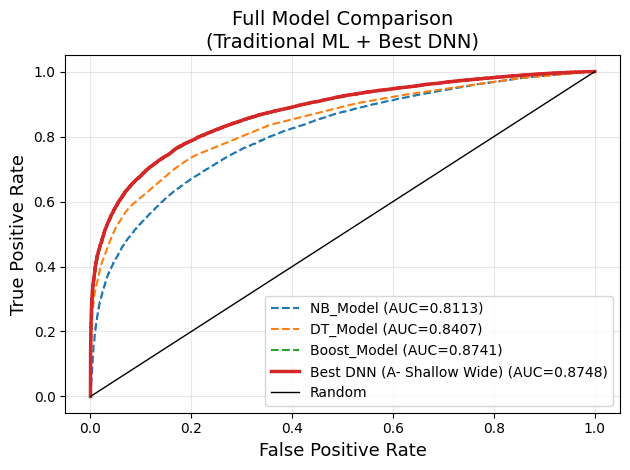


=== AUC Summary ===
Model                                    AUC
---------------------------------------------
NB_Model                              0.8113
DT_Model                              0.8407
Boost_Model                           0.8741
Best DNN (A- Shallow Wide)            0.8748


In [37]:
#Final ROC comparision plot
#plot ROC curves for all classical models and best DNN
#Note: Dashed lines for classical ML algorthms and smooth line for DNN

for label,(_,__,y_te,y_score) in ex4_models.items():
    fpr,tpr,_=roc_curve(y_te,y_score)
    roc_auc=auc(fpr,tpr)
    lw=2.5 if "DNN" in label else 1.5
    ls='-' if "DNN" in label else '--'
    plt.plot(fpr,tpr,linewidth=lw, linestyle=ls, label=f"{label} (AUC={roc_auc:.4f})")

#Reference line for a random classifer (AUC=0.5)
plt.plot([0,1],[0,1], 'k',linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title('Full Model Comparison\n(Traditional ML + Best DNN)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
#Print a ranked AUC summary for all models
print("\n=== AUC Summary ===")
print(f"{'Model':<35} {'AUC':>8}")
print("-" * 45)
for label, (_, __, y_te, y_score) in ex4_models.items():
    print(f"{label:<35} {roc_auc_score(y_te, y_score):>8.4f}")
